Available items:
0 Statistical minimum : Surface elevation
1 Statistical maximum : Surface elevation
2 Statistical mean : Surface elevation


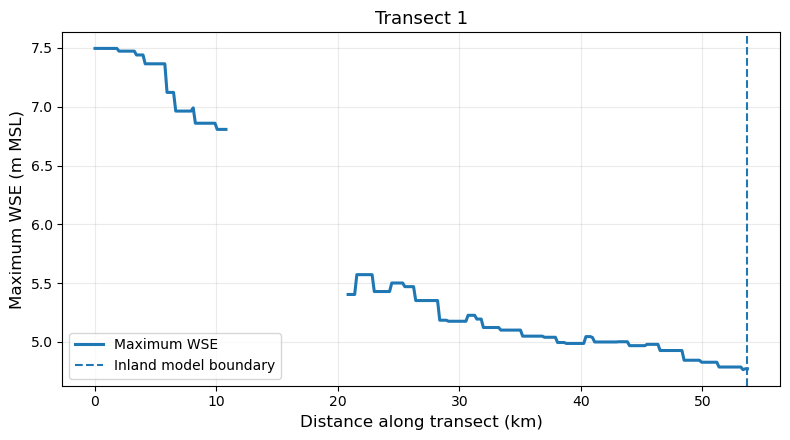

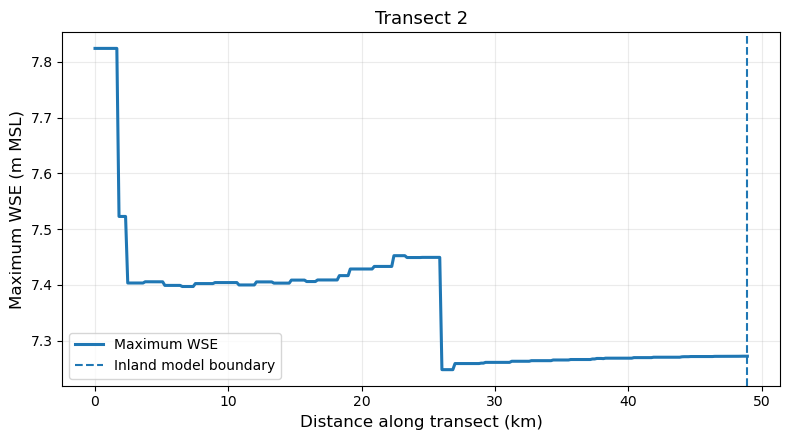

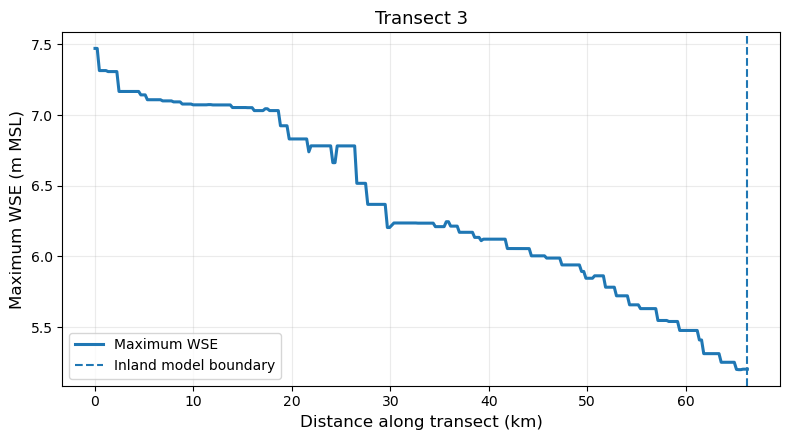

In [1]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# ==========================================================
# DFSU file
# ==========================================================
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\100yr_compound_flood_base.m21fm - Result Files\100yr_compound_flood_base_surface_elevation_stat.dfsu"

# ==========================================================
# Transects: Interior --> Inland model boundary
# ==========================================================
transects = {
    "Transect 1": ((762908, 3175325), (732511, 3219599)),
    "Transect 2": ((681299, 3091404), (650902, 3129730)),
    "Transect 3": ((651563, 3007482), (585813, 3015742))
}

n_points = 300
item_name = "Statistical maximum : Surface elevation"

# ==========================================================
# Open DFSU and read maximum surface elevation
# ==========================================================
dfs = mikeio.open(dfsu_file)

print("Available items:")
for i, item in enumerate(dfs.items):
    print(i, item.name)

ds = dfs.read(items=[item_name])
wse = ds[0].to_numpy().squeeze()

# ==========================================================
# Element coordinates
# ==========================================================
elem = dfs.geometry.element_coordinates
mesh_x, mesh_y = elem[:, 0], elem[:, 1]

tree = cKDTree(np.column_stack((mesh_x, mesh_y)))

# ==========================================================
# Extract and plot WSE profiles
# ==========================================================
for name, ((x1, y1), (x2, y2)) in transects.items():

    x = np.linspace(x1, x2, n_points)
    y = np.linspace(y1, y2, n_points)

    distance_km = np.sqrt((x - x1)**2 + (y - y1)**2) / 1000

    _, idx = tree.query(np.column_stack((x, y)))
    wse_profile = wse[idx]

    # Replace MIKE delete values / extreme invalid values with NaN
    wse_profile = np.where(np.abs(wse_profile) > 1e10, np.nan, wse_profile)

    plt.figure(figsize=(8, 4.5))

    plt.plot(distance_km, wse_profile, lw=2.2, label="Maximum WSE")

    plt.axvline(distance_km[-1], ls="--", lw=1.5,
                label="Inland model boundary")

    plt.xlabel("Distance along transect (km)", fontsize=12)
    plt.ylabel("Maximum WSE (m MSL)", fontsize=12)
    plt.title(name, fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

Available items:
0 Statistical minimum : Surface elevation
1 Statistical maximum : Surface elevation
2 Statistical mean : Surface elevation


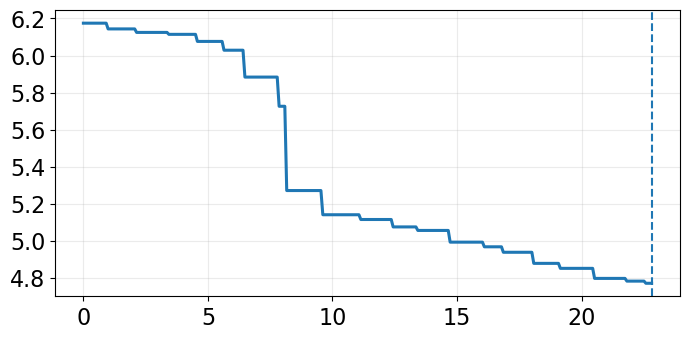

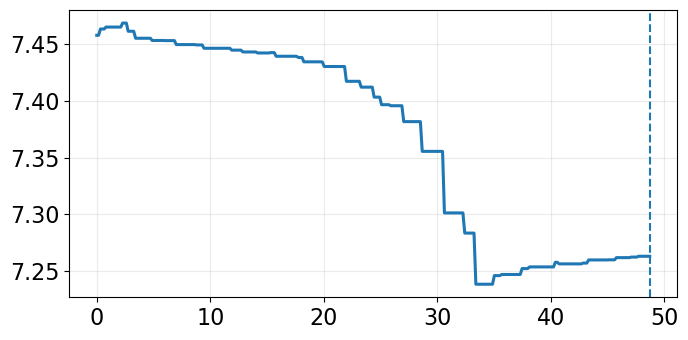

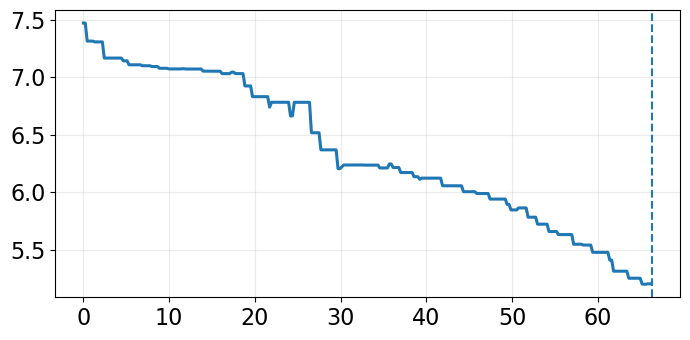

In [12]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# ==========================================================
# DFSU file
# ==========================================================
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\100yr_compound_flood_base.m21fm - Result Files\100yr_compound_flood_base_surface_elevation_stat.dfsu"

# ==========================================================
# Transects: Interior --> Inland model boundary
# ==========================================================
transects = {
    "Transect 1": ((718835, 3201343), (732511, 3219599)),
    "Transect 2": ((659914, 3086025), (635097, 3127925)),
    "Transect 3": ((651563, 3007482), (585813, 3015742))
}

n_points = 300
item_name = "Statistical maximum : Surface elevation"

# ==========================================================
# Open DFSU and read maximum surface elevation
# ==========================================================
dfs = mikeio.open(dfsu_file)

print("Available items:")
for i, item in enumerate(dfs.items):
    print(i, item.name)

ds = dfs.read(items=[item_name])
wse = ds[0].to_numpy().squeeze()

# ==========================================================
# Element coordinates
# ==========================================================
elem = dfs.geometry.element_coordinates
mesh_x, mesh_y = elem[:, 0], elem[:, 1]

tree = cKDTree(np.column_stack((mesh_x, mesh_y)))

# ==========================================================
# Extract and plot WSE profiles
# ==========================================================
for name, ((x1, y1), (x2, y2)) in transects.items():

    x = np.linspace(x1, x2, n_points)
    y = np.linspace(y1, y2, n_points)

    distance_km = np.sqrt((x - x1)**2 + (y - y1)**2) / 1000

    _, idx = tree.query(np.column_stack((x, y)))
    wse_profile = wse[idx]

    # Replace MIKE delete values / extreme invalid values with NaN
    wse_profile = np.where(np.abs(wse_profile) > 1e10, np.nan, wse_profile)

    plt.figure(figsize=(7, 3.5))

    plt.plot(distance_km, wse_profile, lw=2.2, label="Maximum WSE")

    plt.axvline(distance_km[-1], ls="--", lw=1.5,
                label="Inland model boundary")
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.xlabel("Distance along transect (km)", fontsize=12)
    # plt.ylabel("Maximum WSE (m MSL)", fontsize=12)
    # plt.title(name, fontsize=13)
    # plt.legend(fontsize=10)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()